# Adversarial Attack with Frank-Wolfe & Co.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import collections
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    ViTFeatureExtractor,
    ViTForImageClassification,
)

from adversarial_optimization.algorithms.attacks import attack_image
from adversarial_optimization.image_utils import (
    deprocess_tensor_to_pil,
    from_bytes_to_image,
    get_dataset_samples,
)
from adversarial_optimization.model_utils import get_target, model_predict
from adversarial_optimization.plot_utils import plot_different_epsilon_demo


/Users/mattiazza/University/optimisation_for_data_science/group24_Adversarial_Attacks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Attacks' parameters

In [3]:
n_images = 50

epsilons = np.arange(0.1, 0.5 + 0.05, 0.05).round(2)

epsilons_00 = np.arange(0.01, 0.10, 0.01).round(3)

max_iter = 25 

start_attacks = time.time()

## <span style="display:block; text-align:center">MNIST ~ SigLIP2</span>

In [4]:
sigLIP2 = AutoModelForImageClassification.from_pretrained(
    "prithivMLmods/Mnist-Digits-SigLIP2",
    trust_remote_code=True
)

model = sigLIP2
model_name = "siglip2"

sigLIP2_processor = AutoImageProcessor.from_pretrained(
    "prithivMLmods/Mnist-Digits-SigLIP2",
)

model_processor = sigLIP2_processor

dataset_name = "mnist"

n_classes = 10

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 9362.29it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### Attacks 

In [5]:
samples = get_dataset_samples(
    dataset_name = "ylecun/mnist",
    split = "test",
    n_images = n_images,
)

Loading 50 images from the ylecun/mnist dataset


In [6]:
pred_mnist = {
    "true_label": [],
    "pred": [],
    "target_label": [],
    "pred_fw": [],
    "fw_time": [],
    "n_iteration_fw": [],
    "dist_mean_fw": [],
    "dist_max_fw": [],
    "dist_min_fw": [],
    "pred_fw_as": [],
    "fw_as_time": [],
    "n_iteration_fw_as": [],
    "dist_mean_fw_as": [],
    "dist_max_fw_as": [],
    "dist_min_fw_as": [],
    "pred_fw_pair": [],
    "fw_pair_time": [],
    "n_iteration_fw_pair": [],
    "dist_mean_fw_pair": [],
    "dist_max_fw_pair": [],
    "dist_min_fw_pair": [],
    "epsilon": [],
}


In [7]:
i = 0

for epsilon in epsilons:
    for sample in samples:
        image = sample["image"].convert("RGB")
        inputs = model_processor(images=image, return_tensors="pt")["pixel_values"]

        true_label = sample["label"]
        pred = model_predict(model=model, inputs=inputs)

        target = get_target(true_label, n_classes=n_classes)

        pred_mnist["true_label"].append(true_label)
        pred_mnist["pred"].append(pred)
        pred_mnist["target_label"].append(target.item())
        pred_mnist["epsilon"].append(epsilon)

        for algorithm in ["fw", "fw_as", "fw_pair"]:
            print(f"⚙️ Algorithm: {algorithm.upper()} ~ epsilon: {epsilon}\n")
            attacked_image, n_iteration, attack_time = attack_image(
                model=model,
                img_ori=inputs,
                target=target,
                epsilon=epsilon,
                max_iter=max_iter,
                algorithm=algorithm,
            )

            pred_adv = model_predict(model=model, inputs=attacked_image)

            dist_mean = torch.mean(torch.abs(attacked_image - inputs)).item()
            dist_min = torch.min(torch.abs(attacked_image - inputs)).item()
            dist_max = torch.max(torch.abs(attacked_image - inputs)).item()

            pred_mnist[f"pred_{algorithm}"].append(pred_adv)
            pred_mnist[f"{algorithm}_time"].append(attack_time)
            pred_mnist[f"n_iteration_{algorithm}"].append(n_iteration)
            pred_mnist[f"dist_mean_{algorithm}"].append(dist_mean)
            pred_mnist[f"dist_min_{algorithm}"].append(dist_min)
            pred_mnist[f"dist_max_{algorithm}"].append(dist_max)

            print(
                f"True label: {true_label}, \tPred (original): {pred}\nTarget: {target.item()} \tPred (after attack): {pred_adv}\n"
            )
        print(
            f"Processed image {i + 1}/{n_images*len(epsilons)} ✅\n"
        )
        i += 1 

# Change results into a dataframe
df_mnist = pd.DataFrame(pred_mnist)

# Saving results into attack_results
os.makedirs("attack_results", exist_ok=True)

df_mnist.to_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv", index=False)

⚙️ Algorithm: FW ~ epsilon: 0.1

Iteration 0 - Target: 9 - Current prediction: 7
Iteration 1 - Target: 9 - Current prediction: 7
Iteration 2 - Target: 9 - Current prediction: 9

Early stopping at iteration 3 as the target class is reached.

True label: 7, 	Pred (original): 7
Target: 9 	Pred (after attack): 9

⚙️ Algorithm: FW_AS ~ epsilon: 0.1

Iteration: 0
Active set size: 1
FW step
grad: 0.39470022916793823, gamma_mid: 0.5
grad: -6.377862930297852, gamma_mid: 0.25
grad: -1.8074322938919067, gamma_mid: 0.375
grad: -0.2557654082775116, gamma_mid: 0.4375
Iteration: 1
Active set size: 2
FW step
grad: 0.2971465289592743, gamma_mid: 0.5
grad: -0.08783645927906036, gamma_mid: 0.25
grad: 0.02451692521572113, gamma_mid: 0.375
grad: 0.00010979082435369492, gamma_mid: 0.3125
Iteration: 2
Active set size: 3

Early stopping at iteration 2 as the target class is reached.

True label: 7, 	Pred (original): 7
Target: 9 	Pred (after attack): 9

⚙️ Algorithm: FW_PAIR ~ epsilon: 0.1

Iteration: 0
Active

## <span style="display:block; text-align:center">ImageNet ~ ResNet</span>

In [8]:
resNet = timm.create_model("resnet50", pretrained=True).eval().to("cpu")

model = resNet
model_name = "resnet50"

data_config = timm.data.resolve_model_data_config(model)
resNet_processor = timm.data.create_transform(**data_config, is_training=False)

model_processor = resNet_processor

dataset_name = "imagenet_00"
epsilons = epsilons_00

n_classes = 1000

### Attacks

In [9]:
samples = get_dataset_samples(
    dataset_name="imagenet-1k",
    split="validation",
    n_images=n_images,
)

Loading 50 images from the imagenet-1k dataset


In [10]:
pred_imagenet = {
    "true_label": [],
    "pred": [],
    "target_label": [],
    "pred_fw": [],  
    "fw_time": [],
    "n_iteration_fw": [],
    "dist_mean_fw": [],
    "dist_max_fw": [],
    "dist_min_fw": [],
    "pred_fw_as": [],
    "fw_as_time": [],
    "n_iteration_fw_as": [],
    "dist_mean_fw_as": [],
    "dist_max_fw_as": [],
    "dist_min_fw_as": [],
    "pred_fw_pair": [],
    "fw_pair_time": [],
    "n_iteration_fw_pair": [],
    "dist_mean_fw_pair": [],
    "dist_max_fw_pair": [],
    "dist_min_fw_pair": [],
    "epsilon": [],
}


In [11]:
i = 0

for epsilon in epsilons:
    for sample in samples:
        image = sample["image"]

        if image.mode != 'RGB':
            image = image.convert('RGB')

        inputs = model_processor(image).unsqueeze(0)

        true_label = sample["label"]
        pred = model_predict(model=model, inputs=inputs)

        target = get_target(true_label, n_classes=n_classes)

        pred_imagenet["true_label"].append(true_label)
        pred_imagenet["pred"].append(pred)
        pred_imagenet["target_label"].append(target.item())
        pred_imagenet["epsilon"].append(epsilon)

        for algorithm in ["fw", "fw_as", "fw_pair"]:
            print(f"⚙️ Algorithm: {algorithm.upper()} ~ epsilon: {epsilon}\n")
            attacked_image, n_iteration, attack_time = attack_image(
                model=model,
                img_ori=inputs,
                target=target,
                epsilon=epsilon,
                max_iter=max_iter,
                algorithm=algorithm,
            )

            pred_adv = model_predict(model=model, inputs=attacked_image)

            dist_mean = torch.mean(torch.abs(attacked_image - inputs)).item()
            dist_min = torch.min(torch.abs(attacked_image - inputs)).item()
            dist_max = torch.max(torch.abs(attacked_image - inputs)).item()

            pred_imagenet[f"pred_{algorithm}"].append(pred_adv)
            pred_imagenet[f"{algorithm}_time"].append(attack_time)
            pred_imagenet[f"n_iteration_{algorithm}"].append(n_iteration)
            pred_imagenet[f"dist_mean_{algorithm}"].append(dist_mean)
            pred_imagenet[f"dist_min_{algorithm}"].append(dist_min)
            pred_imagenet[f"dist_max_{algorithm}"].append(dist_max)

            print(
                f"True label: {true_label}, \tPred (original): {pred}\nTarget: {target.item()} \tPred (after attack): {pred_adv}\n"
            )
        print(f"Processed image {i + 1}/{n_images * len(epsilons)} ✅\n")
        i += 1

# Change results into a dataframe
df_imagenet = pd.DataFrame(pred_imagenet)

# Saving results into attack_results
os.makedirs("attack_results", exist_ok=True)

df_imagenet.to_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv", index=False)

⚙️ Algorithm: FW ~ epsilon: 0.01

Iteration 0 - Target: 406 - Current prediction: 91
Iteration 1 - Target: 406 - Current prediction: 91
Iteration 2 - Target: 406 - Current prediction: 91
Iteration 3 - Target: 406 - Current prediction: 91
Iteration 4 - Target: 406 - Current prediction: 91
Iteration 5 - Target: 406 - Current prediction: 91
Iteration 6 - Target: 406 - Current prediction: 91
Iteration 7 - Target: 406 - Current prediction: 91
Iteration 8 - Target: 406 - Current prediction: 91
Iteration 9 - Target: 406 - Current prediction: 21
Iteration 10 - Target: 406 - Current prediction: 91
Iteration 11 - Target: 406 - Current prediction: 91
Iteration 12 - Target: 406 - Current prediction: 91
Iteration 13 - Target: 406 - Current prediction: 91
Iteration 14 - Target: 406 - Current prediction: 91
Iteration 15 - Target: 406 - Current prediction: 91
Iteration 16 - Target: 406 - Current prediction: 91
Iteration 17 - Target: 406 - Current prediction: 91
Iteration 18 - Target: 406 - Current pre

## <span style="display:block; text-align:center">FairFace ~ ViT</span>

In [12]:
vit_model = ViTForImageClassification.from_pretrained("nateraw/vit-age-classifier")

model = vit_model
model_name = "vit"

vit_processor = ViTFeatureExtractor.from_pretrained("nateraw/vit-age-classifier")

model_processor = vit_processor

dataset_name = "fairface_00"
epsilons = epsilons_00

n_classes = 9 #10

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 12483.05it/s]
/Users/mattiazza/University/optimisation_for_data_science/group24_Adversarial_Attacks/.venv/lib/python3.12/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


### Attacks

In [13]:
samples_byte = get_dataset_samples(
    dataset_name="nateraw/fairface",
    split="validation",
    n_images=n_images,
)

samples = from_bytes_to_image(samples_byte)


Loading 50 images from the nateraw/fairface dataset


Using the latest cached version of the module from /Users/mattiazza/.cache/huggingface/modules/datasets_modules/datasets/nateraw--fairface/9d7c8b446334b65d582e9a176cefe55c7a92dff164a02e433fe59b5dffdbfe36 (last modified on Thu Jul 10 12:36:09 2025) since it couldn't be found locally at nateraw/fairface, or remotely on the Hugging Face Hub.


In [14]:
pred_fairface = {
    "true_label": [],
    "pred": [],
    "target_label": [],
    "pred_fw": [],
    "fw_time": [],
    "n_iteration_fw": [],
    "dist_mean_fw": [],
    "dist_max_fw": [],
    "dist_min_fw": [],
    "pred_fw_as": [],
    "fw_as_time": [],
    "n_iteration_fw_as": [],
    "dist_mean_fw_as": [],
    "dist_max_fw_as": [],
    "dist_min_fw_as": [],
    "pred_fw_pair": [],
    "fw_pair_time": [],
    "n_iteration_fw_pair": [],
    "dist_mean_fw_pair": [],
    "dist_max_fw_pair": [],
    "dist_min_fw_pair": [],
    "epsilon": [],
}


In [15]:
i = 0

for epsilon in epsilons:
    for sample in samples:
        image = sample["image"].convert("RGB")
        inputs = model_processor(images=image, return_tensors="pt")["pixel_values"]

        true_label = sample["age"]
        pred = model_predict(model=model, inputs=inputs)

        target = get_target(true_label, n_classes=n_classes)

        pred_fairface["true_label"].append(true_label)
        pred_fairface["pred"].append(pred)
        pred_fairface["target_label"].append(target.item())
        pred_fairface["epsilon"].append(epsilon)

        for algorithm in ["fw", "fw_as", "fw_pair"]:
            print(f"⚙️ Algorithm: {algorithm.upper()} ~ epsilon: {epsilon}\n")
            attacked_image, n_iteration, attack_time = attack_image(
                model=model,
                img_ori=inputs,
                target=target,
                epsilon=epsilon,
                max_iter=max_iter,
                algorithm=algorithm,
            )

            pred_adv = model_predict(model=model, inputs=attacked_image)

            dist_mean = torch.mean(torch.abs(attacked_image - inputs)).item()
            dist_min = torch.min(torch.abs(attacked_image - inputs)).item()
            dist_max = torch.max(torch.abs(attacked_image - inputs)).item()

            pred_fairface[f"pred_{algorithm}"].append(pred_adv)
            pred_fairface[f"{algorithm}_time"].append(attack_time)
            pred_fairface[f"n_iteration_{algorithm}"].append(n_iteration)
            pred_fairface[f"dist_mean_{algorithm}"].append(dist_mean)
            pred_fairface[f"dist_min_{algorithm}"].append(dist_min)
            pred_fairface[f"dist_max_{algorithm}"].append(dist_max)

            print(
                f"True label: {true_label}, \tPred (original): {pred}\nTarget: {target.item()} \tPred (after attack): {pred_adv}\n"
            )
        print(f"Processed image {i + 1}/{n_images * len(epsilons)} ✅\n")
        i += 1

# Change results into a dataframe
df_fairface = pd.DataFrame(pred_fairface)

# Saving results into attack_results
os.makedirs("attack_results", exist_ok=True)

df_fairface.to_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv", index=False)


⚙️ Algorithm: FW ~ epsilon: 0.01

Iteration 0 - Target: 5 - Current prediction: 1
Iteration 1 - Target: 5 - Current prediction: 3
Iteration 2 - Target: 5 - Current prediction: 4
Iteration 3 - Target: 5 - Current prediction: 5

Early stopping at iteration 4 as the target class is reached.

True label: 1, 	Pred (original): 1
Target: 5 	Pred (after attack): 5

⚙️ Algorithm: FW_AS ~ epsilon: 0.01

Iteration: 0
Active set size: 1
FW step
grad: -8.587587356567383, gamma_mid: 0.5
grad: -6.91999626159668, gamma_mid: 0.75
grad: -6.51721715927124, gamma_mid: 0.875
grad: -6.850969314575195, gamma_mid: 0.9375
Iteration: 1
Active set size: 2
FW step
grad: -1.1335150003433228, gamma_mid: 0.5
grad: 0.22557441890239716, gamma_mid: 0.75
grad: -0.20299653708934784, gamma_mid: 0.625
grad: -0.007334522902965546, gamma_mid: 0.6875
Iteration: 2
Active set size: 3

Early stopping at iteration 2 as the target class is reached.

True label: 1, 	Pred (original): 1
Target: 5 	Pred (after attack): 5

⚙️ Algorithm

## Total Attacks time

In [16]:
end_attacks = time.time()

print("✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅")
print("✅                                           ✅")
print("✅      ATTACKS FINISHED WITH SUCCESS        ✅")
print("✅                                           ✅")
print("✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅")

total_attack_time = (end_attacks - start_attacks)

print(f"Total attack time: {int(np.floor(total_attack_time/3600))}h {int(np.floor(total_attack_time%60))}m")

✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
✅                                           ✅
✅      ATTACKS FINISHED WITH SUCCESS        ✅
✅                                           ✅
✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
Total attack time: 3h 31m


# Evaluating

In this section we are going to analyze our previous attacks

In [55]:
figsize = (10, 6)

## <span style="display: block; text-align:center">MNIST</span>

In [56]:
dataset_name = "mnist_true"

df_mnist = pd.read_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv")

df_mnist = df_mnist[df_mnist["true_label"] == df_mnist["pred"]]


df_mnist["epsilon"] = df_mnist["epsilon"].round(3)

epsilons = df_mnist["epsilon"].unique()

### Success Rate vs epsilon

Best epsilon values for fw: [0.1, 0.12, 0.14, 0.16]
Best epsilon values for fw_as: [0.1, 0.12, 0.14, 0.16]
Best epsilon values for fw_pair: [0.14, 0.16, 0.2, 0.24]
fw success rates by epsilon: [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0]
fw_as success rates by epsilon: [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 98.0, 98.0, 96.0, 96.0, 94.0, 98.0, 94.0, 94.0, 94.0]
fw_pair success rates by epsilon: [96.0, 96.0, 100.0, 100.0, 98.0, 100.0, 98.0, 100.0, 100.0, 98.0, 96.0, 100.0, 100.0, 98.0, 100.0, 98.0, 100.0, 98.0, 100.0, 98.0, 100.0]


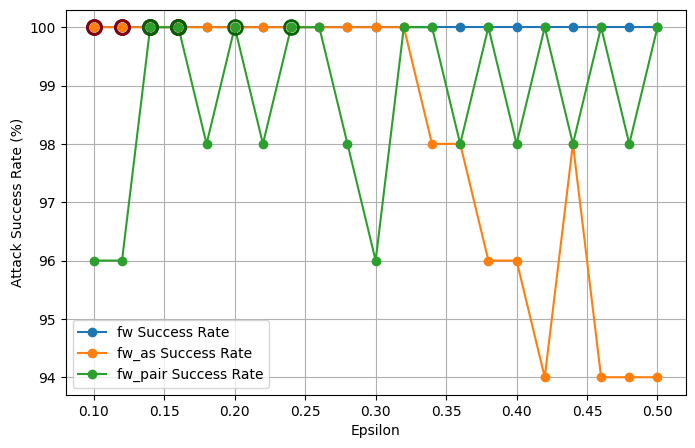

In [57]:
# Calculate attack success rates by epsilon for FW, FW-AS, FW-Pair
success_rates_mnist = {}
success_rates = success_rates_mnist

for algo, pred_col in zip(
    ["fw", "fw_as", "fw_pair"], ["pred_fw", "pred_fw_as", "pred_fw_pair"]
):
    # For each epsilon, calculate success rate
    rates = []
    for eps in epsilons:
        df_eps = df_mnist[df_mnist["epsilon"] == eps]
        correctly_classified = df_eps[df_eps["true_label"] == df_eps["pred"]]
        successful = correctly_classified[
            correctly_classified["target_label"] == correctly_classified[pred_col]
        ]
        rate = len(successful) / max(len(correctly_classified), 1) * 100
        rates.append(rate)
    success_rates[algo] = rates


# Find all epsilon values where all algorithms reach 100%
epsilon_demo = {}
for algo in ["fw", "fw_as", "fw_pair"]:
    # Create tuples of (success_rate, epsilon_value) for sorting
    rates_with_eps = [(rate, eps) for rate, eps in zip(success_rates[algo], epsilons)]
    
    # Sort by success rate (descending), then by epsilon (ascending for ties)
    rates_with_eps.sort(key=lambda x: (-x[0], x[1]))

    # Extract the top 4 epsilon values
    epsilon_demo[algo] = [eps for _, eps in rates_with_eps[:4]]

    print(f"Best epsilon values for {algo}: {epsilon_demo[algo]}")

# Display results
for algo in success_rates:
    print(f"{algo} success rates by epsilon: {success_rates[algo]}")

plt.figure(figsize=(8, 5))
for algo, rates in success_rates.items():
    plt.plot(epsilons, rates, marker="o", label=f"{algo} Success Rate")



for algo_name in ["fw", "fw_as", "fw_pair"]:
    for eps in epsilon_demo[algo_name]:
        idx = np.where(epsilons == eps)[0][0]
        # Use a different color for each algorithm
        if algo_name == "fw":
            color = "darkblue"
        elif algo_name == "fw_as":
            color = "darkred"
        else:  # fw_pair
            color = "darkgreen"

        # Only highlight this algorithm's success rate for its best epsilons
        plt.plot(
            eps,
            success_rates[algo_name][idx],
            "o",
            markersize=10,
            markerfacecolor="none",
            markeredgecolor=color,
            markeredgewidth=2,
        )

plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
# plt.title("Attack Success Rate vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_asr_v_eps1.png")
plt.show()


### Mean Iteration vs epsilon

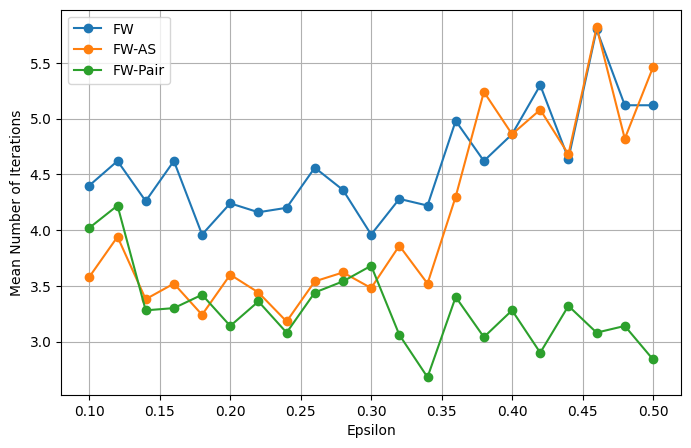

In [58]:
# Select columns from "fw_time" onwards
cols = df_mnist.columns[df_mnist.columns.get_loc("fw_time") :]

# Group by epsilon and calculate the mean for selected columns
mean_stats_mnist = df_mnist.groupby("epsilon")[cols].mean()
mean_stats = mean_stats_mnist

# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["n_iteration_fw"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["n_iteration_fw_as"], marker="o", label="FW-AS")
plt.plot(
    mean_stats.index, mean_stats["n_iteration_fw_pair"], marker="o", label="FW-Pair"
)
plt.xlabel("Epsilon")
plt.ylabel("Mean Number of Iterations")
# plt.title("Mean Iterations vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_iter_v_eps.png")
plt.show()


### Mean Time vs epsilon

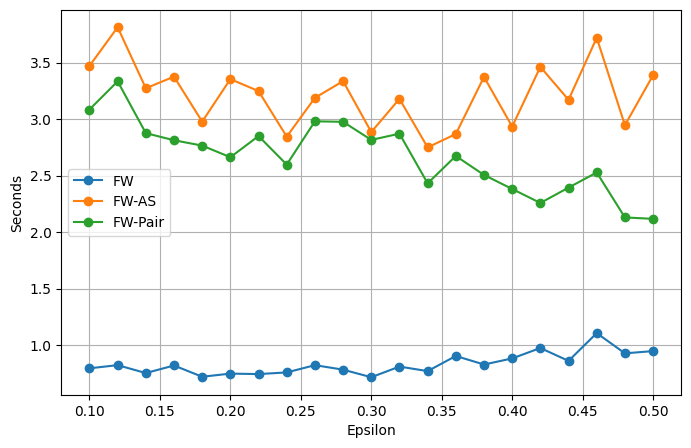

In [59]:
# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["fw_time"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["fw_as_time"], marker="o", label="FW-AS")
plt.plot(
    mean_stats.index, mean_stats["fw_pair_time"], marker="o", label="FW-Pair"
)
plt.xlabel("Epsilon")
plt.ylabel("Seconds")
# plt.title("Mean Time vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_time_v_eps.png")
plt.show()


### Distortion vs epsilon

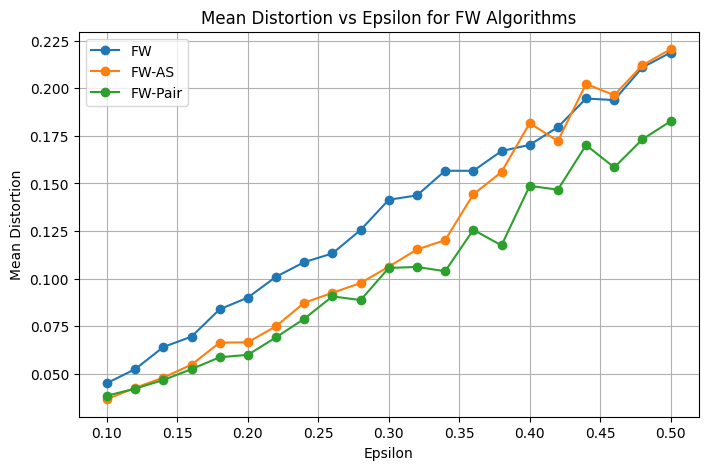

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["dist_mean_fw"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["dist_mean_fw_as"], marker="o", label="FW-AS")
plt.plot(mean_stats.index, mean_stats["dist_mean_fw_pair"], marker="o", label="FW-Pair")
plt.xlabel("Epsilon")
plt.ylabel("Mean Distortion")
plt.title("Mean Distortion vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.show()


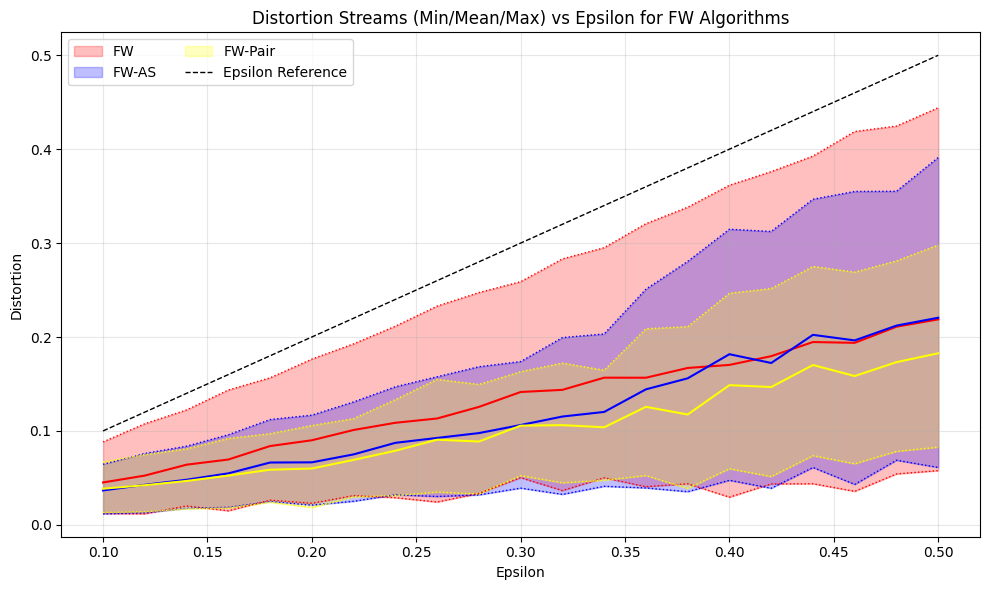

In [61]:
from collections import OrderedDict

plt.figure(figsize=(10, 6))

algos = [
    ("FW", "dist_min_fw", "dist_mean_fw", "dist_max_fw", "red"),
    ("FW-AS", "dist_min_fw_as", "dist_mean_fw_as", "dist_max_fw_as", "blue"),
    ("FW-Pair", "dist_min_fw_pair", "dist_mean_fw_pair", "dist_max_fw_pair", "yellow"),
]

algo_handles = []
algo_labels = []

for label, min_col, mean_col, max_col, color in algos:
    # Fill between min and max for the stream (transparent)
    fill = plt.fill_between(
        mean_stats.index,
        mean_stats[min_col],
        mean_stats[max_col],
        color=color,
        alpha=0.25,
        label=label
    )
    # Min line
    plt.plot(
        mean_stats.index,
        mean_stats[min_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Max line
    plt.plot(
        mean_stats.index,
        mean_stats[max_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Mean line (dotted)
    plt.plot(
        mean_stats.index,
        mean_stats[mean_col],
        color=color,
        linestyle="-",
        linewidth=1.5,
    )
    algo_handles.append(fill)
    algo_labels.append(label)

# Add a dashed line that follows epsilon (diagonal)
ref_line, = plt.plot(mean_stats.index, mean_stats.index, color="black", linestyle="--", linewidth=1, label="Epsilon Reference")

# Only show one legend entry per algorithm color, plus epsilon reference
plt.legend(algo_handles + [ref_line], algo_labels + ["Epsilon Reference"], ncol=2)
plt.xlabel("Epsilon")
plt.ylabel("Distortion")
plt.title("Distortion Streams (Min/Mean/Max) vs Epsilon for FW Algorithms")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/{dataset_name}_dist_v_eps.png")
plt.show()


### Images Attacked

Let's take a look at how different epsilon change the attacks on the image.

In [62]:
# Loading the model and its processor
sigLIP2 = AutoModelForImageClassification.from_pretrained(
    "prithivMLmods/Mnist-Digits-SigLIP2", trust_remote_code=True
)

model = sigLIP2
model_name = "siglip2"

sigLIP2_processor = AutoImageProcessor.from_pretrained(
    "prithivMLmods/Mnist-Digits-SigLIP2",
)

model_processor = sigLIP2_processor

# Choosing parameters for the demo
n_classes = 10
max_iter_demo = 15

# Downloading a sample from the respective dataset
dataset_name = "mnist"

sample_mnist = get_dataset_samples(
    dataset_name=dataset_name,
    split="test",
    n_images=3,
)   

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 16912.52it/s]


Loading 3 images from the mnist dataset


In [63]:
pred_mnist_demo = {
    "pred_fw": [],
    "image_fw": [],  # Image attacked by Frank-Wolfe
    "epsilon_fw": [],
    "pred_fw_as": [],
    "image_fw_as": [],  # Image attacked by Frank-Wolfe with Away Steps
    "epsilon_fw_as": [],
    "pred_fw_pair": [],
    "image_fw_pair": [],  # Image attacked by Frank-Wolfe with Pairwise Steps
    "epsilon_fw_pair": [],
}

algorithms = ["fw", "fw_as", "fw_pair"]

image_original_demo = {"algo": [], "image": [], "label": [], "pred": []}
id = 0
for d, algo in zip(sample_mnist, algorithms):  # For the test we only have one image
    # Preparation for the attacks
    image = d["image"].convert("RGB")  # Convert the image to RGB
    image_original_demo["algo"].append(algo)
    image_original_demo["label"].append(d["label"])  # Extracting true label

    inputs = model_processor(images=image, return_tensors="pt")[
        "pixel_values"
    ]  # Processing our image

    image_original_demo["image"].append(
        deprocess_tensor_to_pil(inputs, model_name=model_name)
    )

    target_label_demo = get_target(
        image_original_demo["label"][-1], n_classes=n_classes
    )  # Choosing the target label for the demo

    # Prediction on original image
    print("🎯 Prediction on original image\n")
    pred_original_demo = model_predict(model=model, inputs=inputs)
    image_original_demo["pred"].append(pred_original_demo)

    for eps in epsilon_demo[algo]:

        pred_mnist_demo[f"epsilon_{algo}"].append(eps)  # Saving current epsilon

        # Attacking the image
        print(f"⚙️ Attack using {algo.upper()} ~ epsilon {eps}\n")
        
        attacked_image, _, _ = attack_image(
            model=model,
            img_ori=inputs,
            target=target_label_demo,
            epsilon=eps,
            max_iter=max_iter_demo,
            algorithm=algo,
        )
        
        # Deprocess and save the image
        pred_mnist_demo[f"image_{algo}"].append(
            deprocess_tensor_to_pil(attacked_image, model_name=model_name)
        )

        # Prediction on the attacked image
        print(f"🎯 Predicting {algo.upper()}'s attacked image")
        pred_mnist_demo[f"pred_{algo}"].append(
            model_predict(
                model=model,
                inputs=attacked_image,
            )
        )

        id += 1
        print(f"\nImage {id}/{len(epsilon_demo[algo])*len(algorithms)} processed ✅\n")


image_original_demo = pd.DataFrame(image_original_demo)

df_demo = pd.DataFrame(pred_mnist_demo)


🎯 Prediction on original image

⚙️ Attack using FW ~ epsilon 0.1

Iteration 0 - Target: 6 - Current prediction: 7
Iteration 1 - Target: 6 - Current prediction: 7
Iteration 2 - Target: 6 - Current prediction: 2
Iteration 3 - Target: 6 - Current prediction: 7
Iteration 4 - Target: 6 - Current prediction: 6

Early stopping at iteration 5 as the target class is reached.

🎯 Predicting FW's attacked image

Image 1/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.12

Iteration 0 - Target: 6 - Current prediction: 7
Iteration 1 - Target: 6 - Current prediction: 7
Iteration 2 - Target: 6 - Current prediction: 2
Iteration 3 - Target: 6 - Current prediction: 7
Iteration 4 - Target: 6 - Current prediction: 6

Early stopping at iteration 5 as the target class is reached.

🎯 Predicting FW's attacked image

Image 2/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.14

Iteration 0 - Target: 6 - Current prediction: 7
Iteration 1 - Target: 6 - Current prediction: 7
Iteration 2 - Target: 6 - Current prediction

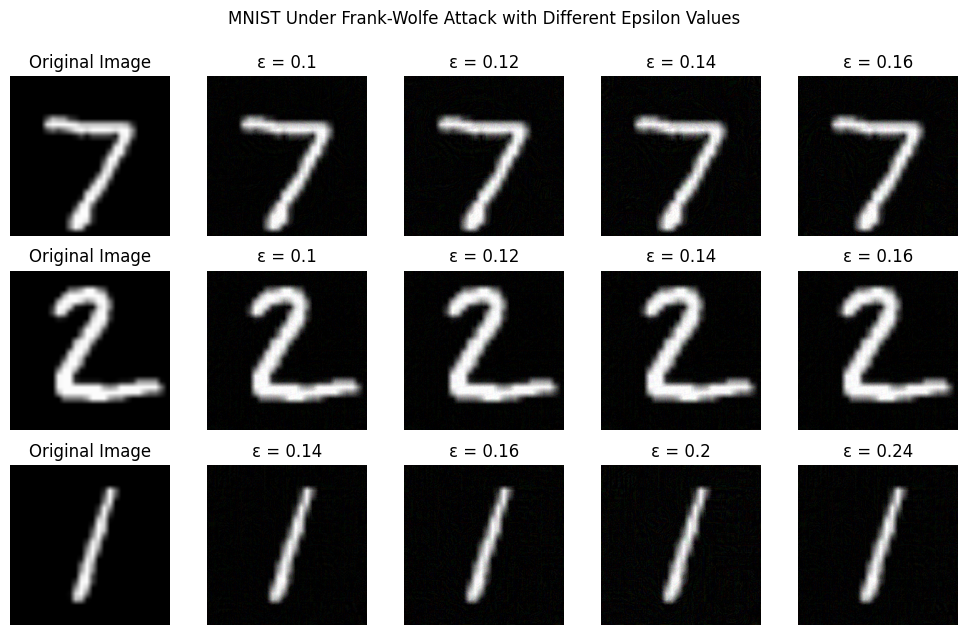

In [64]:
save_name = f"{dataset_name}_different_epsilon_demo"

plot_different_epsilon_demo(
    df=df_demo,
    image_original_demo=image_original_demo,
    algorithms=algorithms,
    dataset_name=dataset_name,
    save_name=save_name,
    savefig=True,
)


### Overall

In [65]:
for algo in success_rates_mnist:
    print(f"{algo} success rates by epsilon: {np.round(np.mean(success_rates_mnist[algo]),2)}")

for algo in ["fw", "fw_as", "fw_pair"]:
    print(f"{algo} mean iteration: {np.round(np.mean(mean_stats_mnist[f'n_iteration_{algo}']),2)}")

for algo in ["fw", "fw_as", "fw_pair"]:
    print(f"{algo} mean time: {np.round(np.mean(mean_stats_mnist[f'{algo}_time']),2)}s")

fw success rates by epsilon: 100.0
fw_as success rates by epsilon: 98.19
fw_pair success rates by epsilon: 98.76
fw mean iteration: 4.58
fw_as mean iteration: 4.1
fw_pair mean iteration: 3.3
fw mean time: 0.83s
fw_as mean time: 3.22s
fw_pair mean time: 2.67s


## ImageNet

In [66]:
dataset_name = "imagenet"
dataset_name_00 = "imagenet_00"

df_imagenet = pd.read_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv")
df_imagenet_00 = pd.read_csv(f"attack_results/{dataset_name_00}_fw_attacks_results.csv")

df_imagenet = df_imagenet[df_imagenet["true_label"] == df_imagenet["pred"]]
df_imagenet_00 = df_imagenet_00[df_imagenet_00["true_label"] == df_imagenet_00["pred"]]

df_imagenet = pd.concat([df_imagenet, df_imagenet_00], ignore_index=True)

df_imagenet["epsilon"] = df_imagenet["epsilon"].round(3)

epsilons = sorted(df_imagenet["epsilon"].unique())

In [67]:
df_imagenet

,true_label,pred,target_label,pred_fw,fw_time,n_iteration_fw,dist_mean_fw,dist_max_fw,dist_min_fw,pred_fw_as,...,dist_mean_fw_as,dist_max_fw_as,dist_min_fw_as,pred_fw_pair,fw_pair_time,n_iteration_fw_pair,dist_mean_fw_pair,dist_max_fw_pair,dist_min_fw_pair,epsilon
0,91,91,426,426,0.452595,4,0.045291,0.090000,0.010000,426,...,0.035571,0.064844,0.005469,426,1.246098,3,0.050433,0.081250,0.018750,0.10
1,171,171,390,390,0.633874,6,0.037233,0.095238,0.000000,390,...,0.012248,0.023617,0.000338,390,4.010857,5,0.013005,0.026663,0.000897,0.10
2,980,980,94,94,1.463743,14,0.025756,0.099048,0.000000,94,...,0.044943,0.097579,0.000004,94,9.420600,14,0.049757,0.093384,0.006616,0.10
3,218,218,21,21,0.533687,5,0.040917,0.093334,0.000000,21,...,0.033163,0.071289,0.008008,21,0.969777,3,0.050299,0.087500,0.012500,0.10
4,19,19,796,796,1.077710,10,0.029200,0.098182,0.000000,796,...,0.042665,0.057373,0.027881,796,2.688508,5,0.050077,0.078467,0.021533,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3856,535,535,628,628,1.535799,13,0.025662,0.089011,0.000000,628,...,0.031382,0.082411,0.000059,479,4.824883,24,0.029418,0.055350,0.002610,0.09
3857,691,691,526,526,0.346688,3,0.045077,0.075000,0.015000,526,...,0.042279,0.073526,0.010780,526,1.213465,3,0.052625,0.086850,0.018270,0.09
3858,70,70,599,599,1.052999,9,0.029463,0.088000,0.000000,599,...,0.048731,0.089417,0.006830,599,3.595769,17,0.041062,0.090000,0.000000,0.09
3859,269,269,328,328,0.832583,7,0.032536,0.086786,0.003214,328,...,0.049158,0.080961,0.016845,328,1.746322,5,0.039394,0.086490,0.000090,0.09


### Success Rate vs epsilon

Best epsilon values for fw: [0.04, 0.05, 0.06, 0.07]
Best epsilon values for fw_as: [0.07, 0.09, 0.22, 0.14]
Best epsilon values for fw_pair: [0.2, 0.24, 0.26, 0.34]
fw success rates by epsilon: [29.545454545454547, 70.45454545454545, 93.18181818181817, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.39393939393939, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0]
fw_as success rates by epsilon: [25.0, 59.09090909090909, 90.9090909090909, 97.72727272727273, 93.18181818181817, 95.45454545454545, 100.0, 97.72727272727273, 100.0, 97.57575757575758, 96.96969696969697, 98.7878787878788, 98.18181818181819, 98.7878787878788, 98.18181818181819, 99.39393939393939, 98.18181818181819, 96.96969696969697, 98.18181818181819, 98.18181818181819, 98.7878787878788, 98.18181818181819, 95.75757575757575, 97.57575757575758, 96.96969696969697, 98.18181818181819, 95.75757575757575, 98.7878787878788, 95.75757575757575, 98.

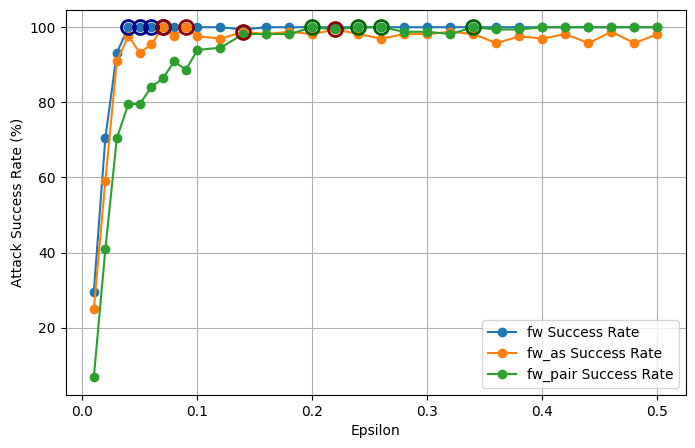

In [68]:
# Calculate attack success rates by epsilon for FW, FW-AS, FW-Pair
success_rates_imagenet = {}
success_rates = success_rates_imagenet

for algo, pred_col in zip(
    ["fw", "fw_as", "fw_pair"], ["pred_fw", "pred_fw_as", "pred_fw_pair"]
):
    # For each epsilon, calculate success rate
    rates = []
    for eps in epsilons:
        df_eps = df_imagenet[df_imagenet["epsilon"] == eps]
        correctly_classified = df_eps[df_eps["true_label"] == df_eps["pred"]]
        successful = correctly_classified[
            correctly_classified["target_label"] == correctly_classified[pred_col]
        ]
        rate = len(successful) / max(len(correctly_classified), 1) * 100
        rates.append(rate)
    success_rates[algo] = rates


# Find all epsilon values where all algorithms reach 100%
epsilon_demo = {}
for algo in ["fw", "fw_as", "fw_pair"]:
    # Create tuples of (success_rate, epsilon_value) for sorting
    rates_with_eps = [(rate, eps) for rate, eps in zip(success_rates[algo], epsilons)]

    # Sort by success rate (descending), then by epsilon (ascending for ties)
    rates_with_eps.sort(key=lambda x: (-x[0], x[1]))

    # Extract the top 4 epsilon values
    epsilon_demo[algo] = [eps for _, eps in rates_with_eps[:4]]

    print(f"Best epsilon values for {algo}: {epsilon_demo[algo]}")

# Display results
for algo in success_rates:
    print(f"{algo} success rates by epsilon: {success_rates[algo]}")

plt.figure(figsize=(8, 5))
for algo, rates in success_rates.items():
    plt.plot(epsilons, rates, marker="o", label=f"{algo} Success Rate")



for algo_name in ["fw", "fw_as", "fw_pair"]:
    for eps in epsilon_demo[algo_name]:
        idx = np.where(epsilons == eps)[0][0]
        # Use a different color for each algorithm
        if algo_name == "fw":
            color = "darkblue"
        elif algo_name == "fw_as":
            color = "darkred"
        else:  # fw_pair
            color = "darkgreen"

        # Only highlight this algorithm's success rate for its best epsilons
        plt.plot(
            eps,
            success_rates[algo_name][idx],
            "o",
            markersize=10,
            markerfacecolor="none",
            markeredgecolor=color,
            markeredgewidth=2,
        )

plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
# plt.title("Attack Success Rate vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_asr_v_eps1.png")
plt.show()


### Mean Iteration vs epsilon

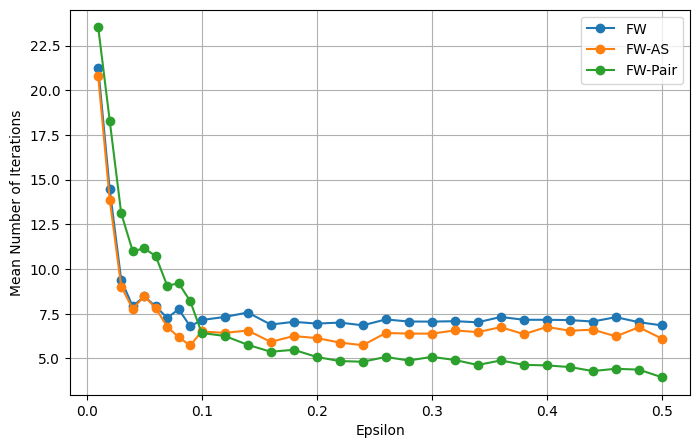

In [69]:
# Select columns from "fw_time" onwards
cols = df_imagenet.columns[df_imagenet.columns.get_loc("fw_time") :]

# Group by epsilon and calculate the mean for selected columns
mean_stats_imagenet = df_imagenet.groupby("epsilon")[cols].mean()
mean_stats = mean_stats_imagenet

# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["n_iteration_fw"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["n_iteration_fw_as"], marker="o", label="FW-AS")
plt.plot(
    mean_stats.index, mean_stats["n_iteration_fw_pair"], marker="o", label="FW-Pair"
)
plt.xlabel("Epsilon")
plt.ylabel("Mean Number of Iterations")
# plt.title("Mean Iterations vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_iter_v_eps.png")
plt.show()


### Mean Time vs epsilon

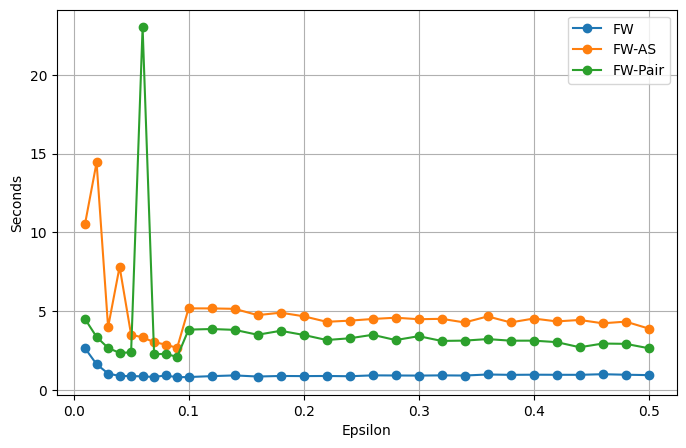

In [70]:
# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["fw_time"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["fw_as_time"], marker="o", label="FW-AS")
plt.plot(mean_stats.index, mean_stats["fw_pair_time"], marker="o", label="FW-Pair")
plt.xlabel("Epsilon")
plt.ylabel("Seconds")
# plt.title("Mean Time vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_time_v_eps.png")
plt.show()


### Distortion vs epsilon

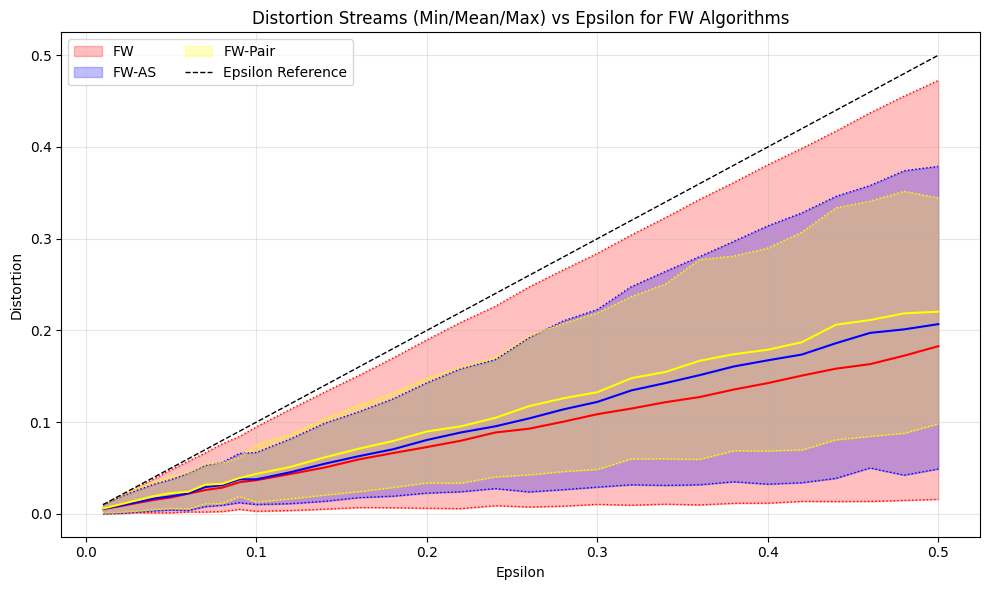

In [71]:
plt.figure(figsize=(10, 6))

algos = [
    ("FW", "dist_min_fw", "dist_mean_fw", "dist_max_fw", "red"),
    ("FW-AS", "dist_min_fw_as", "dist_mean_fw_as", "dist_max_fw_as", "blue"),
    ("FW-Pair", "dist_min_fw_pair", "dist_mean_fw_pair", "dist_max_fw_pair", "yellow"),
]

algo_handles = []
algo_labels = []

for label, min_col, mean_col, max_col, color in algos:
    # Fill between min and max for the stream (transparent)
    fill = plt.fill_between(
        mean_stats.index,
        mean_stats[min_col],
        mean_stats[max_col],
        color=color,
        alpha=0.25,
        label=label,
    )
    # Min line
    plt.plot(
        mean_stats.index,
        mean_stats[min_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Max line
    plt.plot(
        mean_stats.index,
        mean_stats[max_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Mean line (dotted)
    plt.plot(
        mean_stats.index,
        mean_stats[mean_col],
        color=color,
        linestyle="-",
        linewidth=1.5,
    )
    algo_handles.append(fill)
    algo_labels.append(label)

# Add a dashed line that follows epsilon (diagonal)
(ref_line,) = plt.plot(
    mean_stats.index,
    mean_stats.index,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Epsilon Reference",
)

# Only show one legend entry per algorithm color, plus epsilon reference
plt.legend(algo_handles + [ref_line], algo_labels + ["Epsilon Reference"], ncol=2)
plt.xlabel("Epsilon")
plt.ylabel("Distortion")
plt.title("Distortion Streams (Min/Mean/Max) vs Epsilon for FW Algorithms")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/{dataset_name}_dist_v_eps.png")
plt.show()


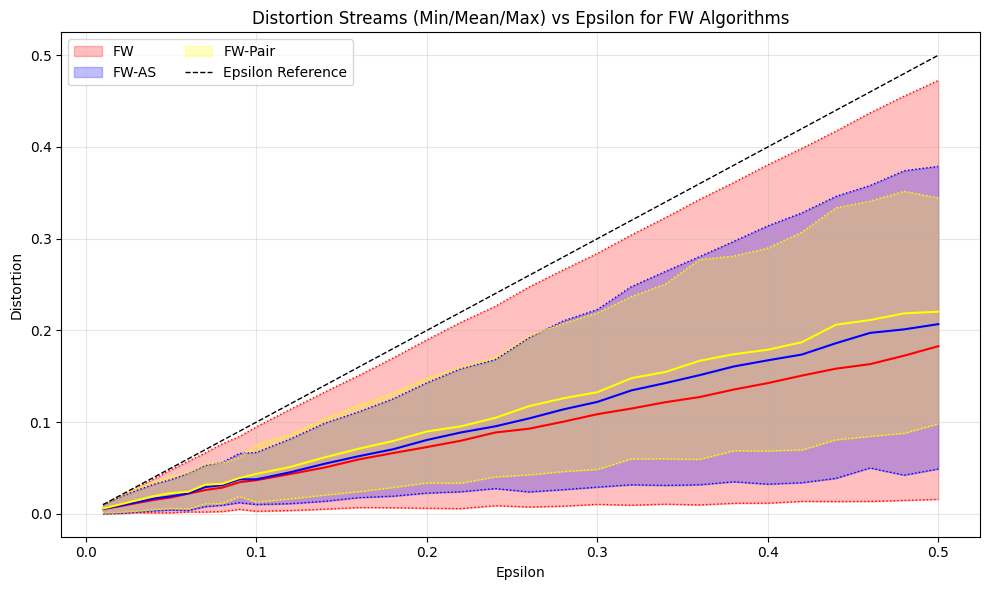

In [72]:
from collections import OrderedDict

plt.figure(figsize=(10, 6))

algos = [
    ("FW", "dist_min_fw", "dist_mean_fw", "dist_max_fw", "red"),
    ("FW-AS", "dist_min_fw_as", "dist_mean_fw_as", "dist_max_fw_as", "blue"),
    ("FW-Pair", "dist_min_fw_pair", "dist_mean_fw_pair", "dist_max_fw_pair", "yellow"),
]

algo_handles = []
algo_labels = []

for label, min_col, mean_col, max_col, color in algos:
    # Fill between min and max for the stream (transparent)
    fill = plt.fill_between(
        mean_stats.index,
        mean_stats[min_col],
        mean_stats[max_col],
        color=color,
        alpha=0.25,
        label=label
    )
    # Min line
    plt.plot(
        mean_stats.index,
        mean_stats[min_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Max line
    plt.plot(
        mean_stats.index,
        mean_stats[max_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Mean line (dotted)
    plt.plot(
        mean_stats.index,
        mean_stats[mean_col],
        color=color,
        linestyle="-",
        linewidth=1.5,
    )
    algo_handles.append(fill)
    algo_labels.append(label)

# Add a dashed line that follows epsilon (diagonal)
ref_line, = plt.plot(mean_stats.index, mean_stats.index, color="black", linestyle="--", linewidth=1, label="Epsilon Reference")

# Only show one legend entry per algorithm color, plus epsilon reference
plt.legend(algo_handles + [ref_line], algo_labels + ["Epsilon Reference"], ncol=2)
plt.xlabel("Epsilon")
plt.ylabel("Distortion")
plt.title("Distortion Streams (Min/Mean/Max) vs Epsilon for FW Algorithms")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Images Attacked

Let's take a look at how different epsilon change the attacks on the image.

In [73]:
# Loading the model and its processor
resNet = timm.create_model("resnet50", pretrained=True).eval().to("cpu")

model = resNet
model_name = "resnet50"

data_config = timm.data.resolve_model_data_config(model)
resNet_processor = timm.data.create_transform(**data_config, is_training=False)

model_processor = resNet_processor

# Choosing parameters for the demo
n_classes = 1000
max_iter_demo = 15


# Downloading a sample from the respective dataset
dataset_name = "imagenet"

sample_imagenet = get_dataset_samples(
    dataset_name="imagenet-1k",
    split="test",
    n_images=3,
)   

Loading 3 images from the imagenet-1k dataset


In [74]:
pred_imagenet_demo = {
    "pred_fw": [],
    "image_fw": [],  # Image attacked by Frank-Wolfe
    "epsilon_fw": [],
    "pred_fw_as": [],
    "image_fw_as": [],  # Image attacked by Frank-Wolfe with Away Steps
    "epsilon_fw_as": [],
    "pred_fw_pair": [],
    "image_fw_pair": [],  # Image attacked by Frank-Wolfe with Pairwise Steps
    "epsilon_fw_pair": [],
}

algorithms = ["fw", "fw_as", "fw_pair"]
# epsilon_demo = np.array([0.1, 0.2, 0.3, 0.4]) # Epsilon values for the demo

    
image_original_demo = {"algo": [], "image": [], "label": [], "pred": []}
id = 0
for d, algo in zip(sample_imagenet, algorithms):  # For the test we only have one image
    # Preparation for the attacks
    if d["image"].mode != 'RGB':  # Convert the image to RGB if not already in that mode
        d["image"] = d["image"].convert('RGB')

    image = d["image"]
    image_original_demo["algo"].append(algo)
    image_original_demo["label"].append(d["label"])

    inputs = model_processor(image).unsqueeze(
        0
    ) # Processing our image
    image_original_demo["image"].append(deprocess_tensor_to_pil(inputs, model_name=model_name))

    target_label_demo = get_target(d["label"], n_classes=n_classes) # Choosing the target label for the demo 

    # Prediction on original image
    print("🎯 Prediction on original image\n")
    pred_original_demo = model_predict(model=model, inputs=inputs)
    image_original_demo["pred"].append(pred_original_demo)

    for eps in epsilon_demo[algo]:

        pred_imagenet_demo[f"epsilon_{algo}"].append(eps)  # Saving current epsilon

        # Attacking the image
        print(f"⚙️ Attack using {algo.upper()} ~ epsilon {eps}\n")
        
        attacked_image, _, _ = attack_image(
            model=model,
            img_ori=inputs,
            target=target_label_demo,
            epsilon=eps,
            max_iter=max_iter_demo,
            algorithm=algo,
        )
        
        # Deprocess and save the image
        pred_imagenet_demo[f"image_{algo}"].append(
            deprocess_tensor_to_pil(attacked_image, model_name=model_name)
        )

        # Prediction on the attacked image
        print(f"🎯 Predicting {algo.upper()}'s attacked image")
        pred_imagenet_demo[f"pred_{algo}"].append(
            model_predict(
                model=model,
                inputs=attacked_image,
            )
        )

        id += 1
        print(f"\nImage {id}/{len(epsilon_demo[algo])*len(algorithms)} processed ✅\n")

image_original_demo = pd.DataFrame(image_original_demo)
df_demo = pd.DataFrame(pred_imagenet_demo)

🎯 Prediction on original image

⚙️ Attack using FW ~ epsilon 0.04

Iteration 0 - Target: 298 - Current prediction: 236
Iteration 1 - Target: 298 - Current prediction: 346
Iteration 2 - Target: 298 - Current prediction: 234
Iteration 3 - Target: 298 - Current prediction: 232
Iteration 4 - Target: 298 - Current prediction: 298

Early stopping at iteration 5 as the target class is reached.

🎯 Predicting FW's attacked image

Image 1/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.05

Iteration 0 - Target: 298 - Current prediction: 236
Iteration 1 - Target: 298 - Current prediction: 346
Iteration 2 - Target: 298 - Current prediction: 234
Iteration 3 - Target: 298 - Current prediction: 298

Early stopping at iteration 4 as the target class is reached.

🎯 Predicting FW's attacked image

Image 2/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.06

Iteration 0 - Target: 298 - Current prediction: 236
Iteration 1 - Target: 298 - Current prediction: 346
Iteration 2 - Target: 298 - Current prediction:

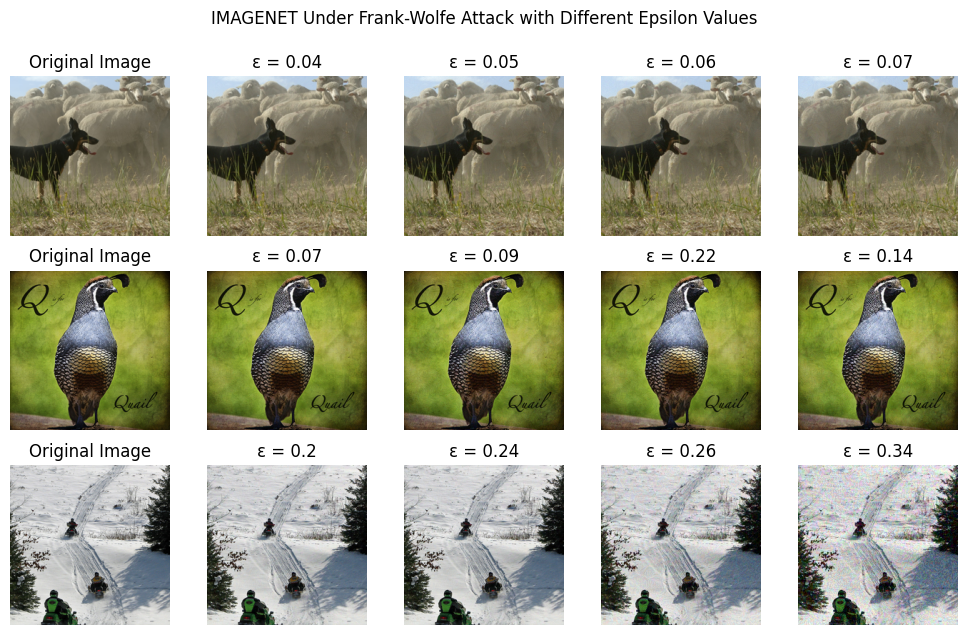

In [75]:
save_name = f"{dataset_name}_different_epsilon_demo"

plot_different_epsilon_demo(
    df=df_demo,
    image_original_demo=image_original_demo,
    algorithms=algorithms,
    dataset_name=dataset_name,
    save_name=save_name,
    savefig=True,
)

### Overall

In [76]:
for algo in success_rates_imagenet:
    print(
        f"{algo} success rates by epsilon: {np.round(np.mean(success_rates_imagenet[algo]), 2)}"
    )

for algo in ["fw", "fw_as", "fw_pair"]:
    print(
        f"{algo} mean iteration: {np.round(np.mean(mean_stats_imagenet[f'n_iteration_{algo}']), 2)}"
    )

for algo in ["fw", "fw_as", "fw_pair"]:
    print(
        f"{algo} mean time: {np.round(np.mean(mean_stats_imagenet[f'{algo}_time']), 2)}s"
    )


fw success rates by epsilon: 96.42
fw_as success rates by epsilon: 93.75
fw_pair success rates by epsilon: 90.14
fw mean iteration: 8.02
fw_as mean iteration: 7.34
fw_pair mean iteration: 7.29
fw mean time: 1.0s
fw_as mean time: 4.93s
fw_pair mean time: 3.79s


## <span style="display: block; text-align:center">FairFace</span>

In [77]:
dataset_name = "fairface"
dataset_name_00 = "fairface_00"

df_fairface = pd.read_csv(f"attack_results/{dataset_name}_fw_attacks_results.csv")
df_fairface_00 = pd.read_csv(f"attack_results/{dataset_name_00}_fw_attacks_results.csv")

df_fairface = df_fairface[df_fairface["true_label"] == df_fairface["pred"]]
df_fairface_00 = df_fairface_00[df_fairface_00["true_label"] == df_fairface_00["pred"]]

df_fairface = pd.concat([df_fairface, df_fairface_00], ignore_index=True)

df_fairface["epsilon"] = df_fairface["epsilon"].round(3)

epsilons = df_fairface["epsilon"].unique()

### Success Rate vs epsilon

Best epsilon values for fw: [0.03, 0.04, 0.05, 0.06]
Best epsilon values for fw_as: [0.03, 0.04, 0.05, 0.06]
Best epsilon values for fw_pair: [0.05, 0.06, 0.07, 0.08]
fw success rates by epsilon: [100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.    94.29  97.14 100.   100.   100.   100.   100.   100.   100.  ]
fw_as success rates by epsilon: [100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.   100.   100.   100.   100.   100.   100.   100.   100.   100.
 100.    94.29  97.14 100.   100.   100.   100.   100.   100.   100.  ]
fw_pair success rates by epsilon: [ 99.19 100.   100.   100.   100.   100.   100.   100.    99.19 100.
  99.19  99.19  99.19 100.   100.    99.19 100.   100.   100.   100.
 100.    68.57  91.43  97.14  97.14 100.   100.   100.   100.   100.  ]


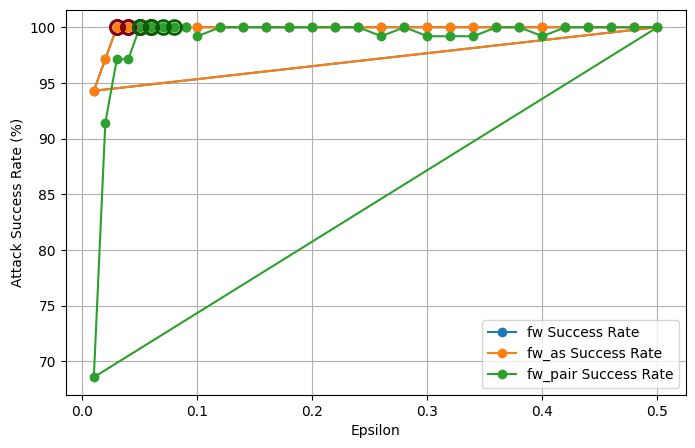

In [78]:
# Calculate attack success rates by epsilon for FW, FW-AS, FW-Pair
success_rates_fairface = {}
success_rates = success_rates_fairface

for algo, pred_col in zip(
    ["fw", "fw_as", "fw_pair"], ["pred_fw", "pred_fw_as", "pred_fw_pair"]
):
    # For each epsilon, calculate success rate
    rates = []
    for eps in epsilons:
        df_eps = df_fairface[df_fairface["epsilon"] == eps]
        correctly_classified = df_eps[df_eps["true_label"] == df_eps["pred"]]
        successful = correctly_classified[
            correctly_classified["target_label"] == correctly_classified[pred_col]
        ]
        rate = len(successful) / max(len(correctly_classified), 1) * 100
        rates.append(rate)
    success_rates[algo] = np.round(rates, 2)


# Find all epsilon values where all algorithms reach 100%
epsilon_demo = {}
for algo in ["fw", "fw_as", "fw_pair"]:
    # Create tuples of (success_rate, epsilon_value) for sorting
    rates_with_eps = [(rate, eps) for rate, eps in zip(success_rates[algo], epsilons)]

    # Sort by success rate (descending), then by epsilon (ascending for ties)
    rates_with_eps.sort(key=lambda x: (-x[0], x[1]))

    # Extract the top 4 epsilon values
    epsilon_demo[algo] = [eps for _, eps in rates_with_eps[:4]]

    print(f"Best epsilon values for {algo}: {epsilon_demo[algo]}")

# Display results
for algo in success_rates:
    print(f"{algo} success rates by epsilon: {success_rates[algo]}")

plt.figure(figsize=(8, 5))
for algo, rates in success_rates.items():
    plt.plot(epsilons, rates, marker="o", label=f"{algo} Success Rate")


for algo_name in ["fw", "fw_as", "fw_pair"]:
    for eps in epsilon_demo[algo_name]:
        idx = np.where(epsilons == eps)[0][0]
        # Use a different color for each algorithm
        if algo_name == "fw":
            color = "darkblue"
        elif algo_name == "fw_as":
            color = "darkred"
        else:  # fw_pair
            color = "darkgreen"

        # Only highlight this algorithm's success rate for its best epsilons
        plt.plot(
            eps,
            success_rates[algo_name][idx],
            "o",
            markersize=10,
            markerfacecolor="none",
            markeredgecolor=color,
            markeredgewidth=2,
        )

plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
# plt.title("Attack Success Rate vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_asr_v_eps1.png")
plt.show()


### Mean Iteration vs epsilon

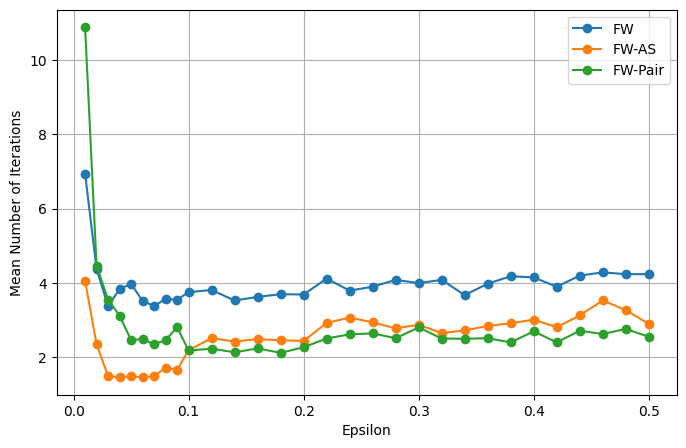

In [79]:
# Select columns from "fw_time" onwards
cols = df_fairface.columns[df_fairface.columns.get_loc("fw_time") :]

# Group by epsilon and calculate the mean for selected columns
mean_stats_fairface = df_fairface.groupby("epsilon")[cols].mean()
mean_stats = mean_stats_fairface

# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["n_iteration_fw"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["n_iteration_fw_as"], marker="o", label="FW-AS")
plt.plot(
    mean_stats.index, mean_stats["n_iteration_fw_pair"], marker="o", label="FW-Pair"
)
plt.xlabel("Epsilon")
plt.ylabel("Mean Number of Iterations")
# plt.title("Mean Iterations vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_iter_v_eps.png")
plt.show()


### Mean Time vs epsilon

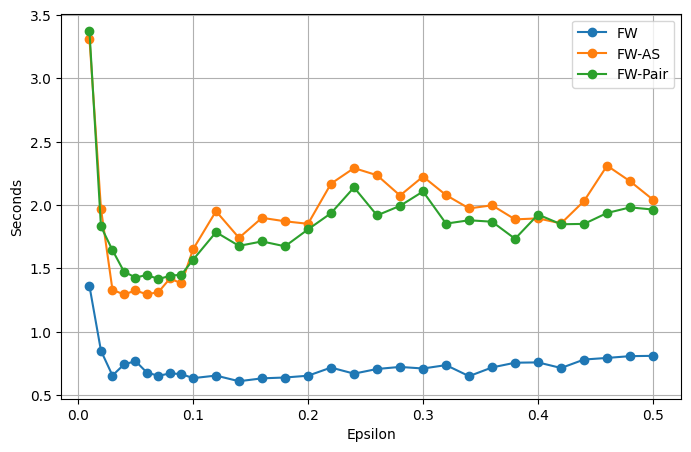

In [80]:
# print(mean_stats)

plt.figure(figsize=(8, 5))
plt.plot(mean_stats.index, mean_stats["fw_time"], marker="o", label="FW")
plt.plot(mean_stats.index, mean_stats["fw_as_time"], marker="o", label="FW-AS")
plt.plot(
    mean_stats.index, mean_stats["fw_pair_time"], marker="o", label="FW-Pair"
)
plt.xlabel("Epsilon")
plt.ylabel("Seconds")
# plt.title("Mean Time vs Epsilon for FW Algorithms")
plt.legend()
plt.grid(True)
plt.savefig(f"plots/{dataset_name}_time_v_eps.png")
plt.show()


### Distortion vs epsilon

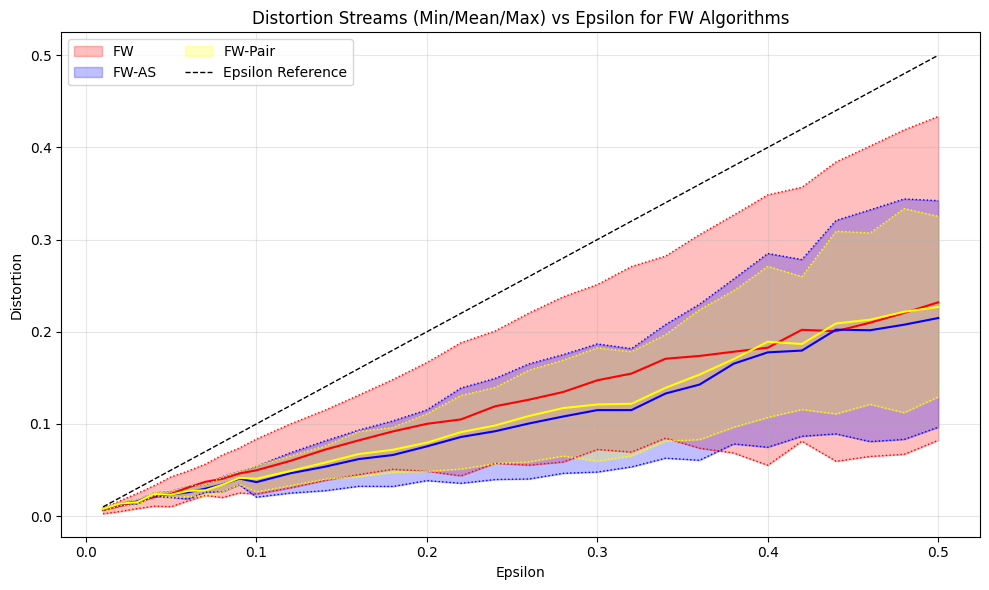

In [81]:
plt.figure(figsize=(10, 6))

algos = [
    ("FW", "dist_min_fw", "dist_mean_fw", "dist_max_fw", "red"),
    ("FW-AS", "dist_min_fw_as", "dist_mean_fw_as", "dist_max_fw_as", "blue"),
    ("FW-Pair", "dist_min_fw_pair", "dist_mean_fw_pair", "dist_max_fw_pair", "yellow"),
]

algo_handles = []
algo_labels = []

for label, min_col, mean_col, max_col, color in algos:
    # Fill between min and max for the stream (transparent)
    fill = plt.fill_between(
        mean_stats.index,
        mean_stats[min_col],
        mean_stats[max_col],
        color=color,
        alpha=0.25,
        label=label,
    )
    # Min line
    plt.plot(
        mean_stats.index,
        mean_stats[min_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Max line
    plt.plot(
        mean_stats.index,
        mean_stats[max_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Mean line (dotted)
    plt.plot(
        mean_stats.index,
        mean_stats[mean_col],
        color=color,
        linestyle="-",
        linewidth=1.5,
    )
    algo_handles.append(fill)
    algo_labels.append(label)

# Add a dashed line that follows epsilon (diagonal)
(ref_line,) = plt.plot(
    mean_stats.index,
    mean_stats.index,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Epsilon Reference",
)

# Only show one legend entry per algorithm color, plus epsilon reference
plt.legend(algo_handles + [ref_line], algo_labels + ["Epsilon Reference"], ncol=2)
plt.xlabel("Epsilon")
plt.ylabel("Distortion")
plt.title("Distortion Streams (Min/Mean/Max) vs Epsilon for FW Algorithms")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"plots/{dataset_name}_dist_v_eps.png")
plt.show()


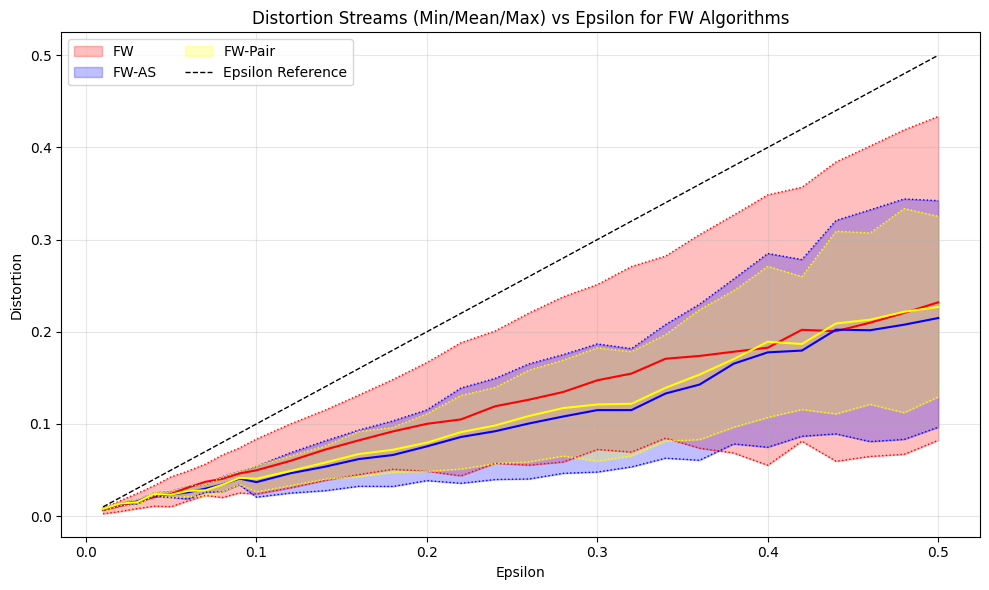

In [82]:
from collections import OrderedDict

plt.figure(figsize=(10, 6))

algos = [
    ("FW", "dist_min_fw", "dist_mean_fw", "dist_max_fw", "red"),
    ("FW-AS", "dist_min_fw_as", "dist_mean_fw_as", "dist_max_fw_as", "blue"),
    ("FW-Pair", "dist_min_fw_pair", "dist_mean_fw_pair", "dist_max_fw_pair", "yellow"),
]

algo_handles = []
algo_labels = []

for label, min_col, mean_col, max_col, color in algos:
    # Fill between min and max for the stream (transparent)
    fill = plt.fill_between(
        mean_stats.index,
        mean_stats[min_col],
        mean_stats[max_col],
        color=color,
        alpha=0.25,
        label=label
    )
    # Min line
    plt.plot(
        mean_stats.index,
        mean_stats[min_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Max line
    plt.plot(
        mean_stats.index,
        mean_stats[max_col],
        color=color,
        linestyle=":",
        linewidth=1,
    )
    # Mean line (dotted)
    plt.plot(
        mean_stats.index,
        mean_stats[mean_col],
        color=color,
        linestyle="-",
        linewidth=1.5,
    )
    algo_handles.append(fill)
    algo_labels.append(label)

# Add a dashed line that follows epsilon (diagonal)
ref_line, = plt.plot(mean_stats.index, mean_stats.index, color="black", linestyle="--", linewidth=1, label="Epsilon Reference")

# Only show one legend entry per algorithm color, plus epsilon reference
plt.legend(algo_handles + [ref_line], algo_labels + ["Epsilon Reference"], ncol=2)
plt.xlabel("Epsilon")
plt.ylabel("Distortion")
plt.title("Distortion Streams (Min/Mean/Max) vs Epsilon for FW Algorithms")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Images Attacked

Let's take a look at how different epsilon change the attacks on the image.

In [83]:
vit_model = ViTForImageClassification.from_pretrained("nateraw/vit-age-classifier")

model = vit_model
model_name = "vit"

vit_processor = ViTFeatureExtractor.from_pretrained("nateraw/vit-age-classifier")

model_processor = vit_processor

n_classes = 9
max_iter_demo = 15

# Downloading a sample from the respective dataset
dataset_name = "fairface"

sample_fairface = get_dataset_samples(
    dataset_name="nateraw/fairface",
    split="validation",
    n_images=3,
)   

sample_fairface = from_bytes_to_image(sample_fairface)

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 10754.63it/s]
/Users/mattiazza/University/optimisation_for_data_science/group24_Adversarial_Attacks/.venv/lib/python3.12/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Loading 3 images from the nateraw/fairface dataset


Using the latest cached version of the module from /Users/mattiazza/.cache/huggingface/modules/datasets_modules/datasets/nateraw--fairface/9d7c8b446334b65d582e9a176cefe55c7a92dff164a02e433fe59b5dffdbfe36 (last modified on Thu Jul 10 12:36:09 2025) since it couldn't be found locally at nateraw/fairface, or remotely on the Hugging Face Hub.


In [84]:
pred_fairface_demo = {
    "pred_fw": [],
    "image_fw": [],  # Image attacked by Frank-Wolfe
    "epsilon_fw": [],
    "pred_fw_as": [],
    "image_fw_as": [],  # Image attacked by Frank-Wolfe with Away Steps
    "epsilon_fw_as": [],
    "pred_fw_pair": [],
    "image_fw_pair": [],  # Image attacked by Frank-Wolfe with Pairwise Steps
    "epsilon_fw_pair": [],
}

algorithms = ["fw", "fw_as", "fw_pair"]

image_original_demo = {"algo": [], "image": [], "label": [], "pred": []}
id = 0
for d, algo in zip(sample_fairface, algorithms): # For the test we only have one image
    
    # Preparation for the attacks
    image = d["image"].convert("RGB")  # Convert the image to RGB
    image_original_demo["algo"].append(algo)
    image_original_demo["label"].append(d["age"]) # Extracting true label

    inputs = model_processor(images=image, return_tensors="pt")["pixel_values"] # Processing our image

    image_original_demo["image"].append(deprocess_tensor_to_pil(inputs, model_name=model_name))
    target_label_demo = get_target(image_original_demo["label"][-1], n_classes=n_classes) # Choosing the target label for the demo

    # Prediction on original image
    print("🎯 Prediction on original image\n")
    pred_original_demo = model_predict(model=model, inputs=inputs)
    image_original_demo["pred"].append(pred_original_demo)

    # for algo in algorithms:
    for eps in epsilon_demo[algo]:

        pred_fairface_demo[f"epsilon_{algo}"].append(eps)  # Saving current epsilon

        # Attacking the image
        print(f"⚙️ Attack using {algo.upper()} ~ epsilon {eps}\n")
        
        attacked_image, _, _ = attack_image(
            model=model,
            img_ori=inputs,
            target=target_label_demo,
            epsilon=eps,
            max_iter=max_iter_demo,
            algorithm=algo,
        )
        
        # Deprocess and save the image
        pred_fairface_demo[f"image_{algo}"].append(
            deprocess_tensor_to_pil(attacked_image, model_name=model_name)
        )

        # Prediction on the attacked image
        print(f"🎯 Predicting {algo.upper()}'s attacked image")
        pred_fairface_demo[f"pred_{algo}"].append(
            model_predict(
                model=model,
                inputs=attacked_image,
            )
        )

        id += 1
        print(f"\nImage {id}/{len(epsilon_demo[algo])*len(algorithms)} processed ✅\n")

image_original_demo = pd.DataFrame(image_original_demo)
df_demo = pd.DataFrame(pred_fairface_demo)

🎯 Prediction on original image

⚙️ Attack using FW ~ epsilon 0.03

Iteration 0 - Target: 7 - Current prediction: 1
Iteration 1 - Target: 7 - Current prediction: 1
Iteration 2 - Target: 7 - Current prediction: 7

Early stopping at iteration 3 as the target class is reached.

🎯 Predicting FW's attacked image

Image 1/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.04

Iteration 0 - Target: 7 - Current prediction: 1
Iteration 1 - Target: 7 - Current prediction: 1
Iteration 2 - Target: 7 - Current prediction: 7

Early stopping at iteration 3 as the target class is reached.

🎯 Predicting FW's attacked image

Image 2/12 processed ✅

⚙️ Attack using FW ~ epsilon 0.05

Iteration 0 - Target: 7 - Current prediction: 1
Iteration 1 - Target: 7 - Current prediction: 1
Iteration 2 - Target: 7 - Current prediction: 8
Iteration 3 - Target: 7 - Current prediction: 2
Iteration 4 - Target: 7 - Current prediction: 7

Early stopping at iteration 5 as the target class is reached.

🎯 Predicting FW's attacked 

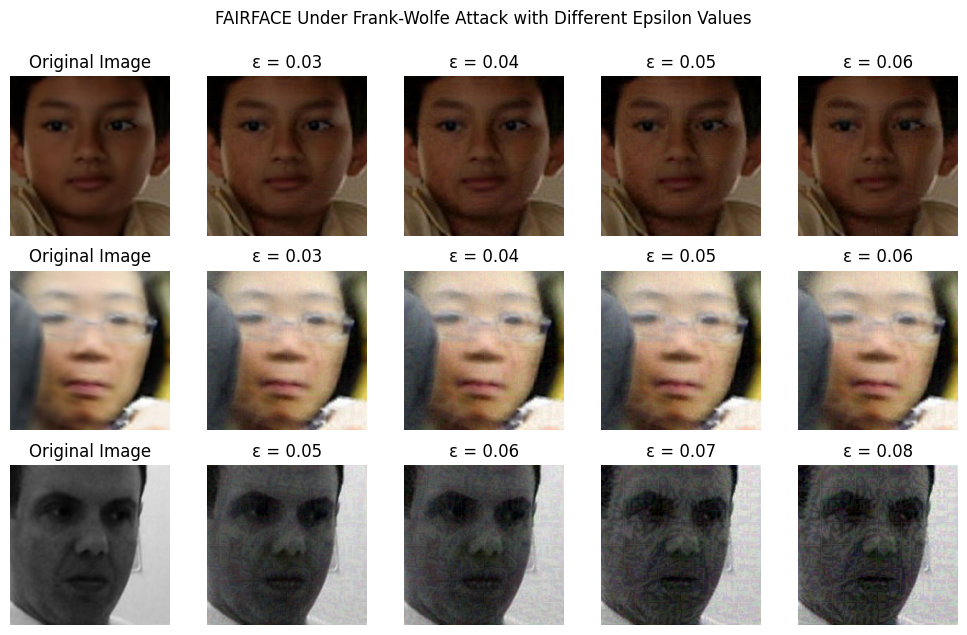

In [85]:
save_name = f"{dataset_name}_different_epsilon_demo"

plot_different_epsilon_demo(
    df=df_demo,
    image_original_demo=image_original_demo,
    algorithms=algorithms,
    dataset_name=dataset_name,
    save_name=save_name,
    savefig=True,
)

In [86]:
### Overall
for algo in success_rates_fairface:
    print(
        f"{algo} success rates by epsilon: {np.round(np.mean(success_rates_fairface[algo]), 2)}"
    )

for algo in ["fw", "fw_as", "fw_pair"]:
    print(
        f"{algo} mean iteration: {np.round(np.mean(mean_stats_fairface[f'n_iteration_{algo}']), 2)}"
    )
    

for algo in ["fw", "fw_as", "fw_pair"]:
    print(
        f"{algo} mean time: {np.round(np.mean(mean_stats_fairface[f'{algo}_time']), 2)}s"
    )


fw success rates by epsilon: 99.71
fw_as success rates by epsilon: 99.71
fw_pair success rates by epsilon: 98.31
fw mean iteration: 3.98
fw_as mean iteration: 2.53
fw_pair mean iteration: 2.88
fw mean time: 0.73s
fw_as mean time: 1.9s
fw_pair mean time: 1.82s
